# Stacking galaxy-cluster weak-lensing profiles — a Bayesian tutorial

**Who this is for.** Anyone comfortable with basic Python and a first course in probability. You do *not*
need prior experience with MCMC or hierarchical models — we build them up step by step.

**What you will learn.**
1. How a Bayesian **posterior** is built from a **likelihood** and a **prior**, and how to sample it with MCMC.
2. The two ways people *stack* many noisy clusters — **join-then-fit (JtF)** and **fit-then-join (FtJ)** —
   and the exact equations behind each.
3. Why one common form of the FtJ likelihood (with a `1/N_c`) is **broken**: its uncertainty never
   improves as you add clusters.
4. How **hierarchical Bayesian inference** recovers the population *mean and scatter*, and how
   **posterior reuse** (importance sampling) makes it cheap.

We use a deliberately simple "toy" forward model so that every posterior is a Gaussian we can also work out
by hand. That lets us **check** the MCMC against pen-and-paper answers and **see** exactly where the bug is.

> One-time setup: `pip install "numpy<2" emcee colossus "matplotlib<3.9"`

In [1]:
# Scientific Python.  `emcee` is a widely used MCMC sampler (Foreman-Mackey et al. 2013).
import numpy as np
import emcee
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 12, "figure.figsize": (6, 4)})

# Fix the random seed so the whole notebook is reproducible (identical numbers every run).
np.random.seed(2807)

print("emcee :", emcee.__version__)
print("numpy :", np.__version__)

emcee : 3.1.6
numpy : 1.26.4


## 0. A 30-second Bayesian refresher

For parameters $\theta$ and data $d$, **Bayes' theorem** is

$$\underbrace{p(\theta \mid d)}_{\text{posterior}}
   = \frac{\overbrace{p(d \mid \theta)}^{\text{likelihood}}\;\overbrace{p(\theta)}^{\text{prior}}}{p(d)}
   \;\propto\; \mathcal{L}(\theta)\,\pi(\theta).$$

- the **likelihood** $\mathcal L(\theta)=p(d\mid\theta)$ — how probable the data are for given parameters;
- the **prior** $\pi(\theta)$ — what we believed before seeing the data;
- the **posterior** $p(\theta\mid d)$ — our updated belief, the thing we want.

MCMC draws samples from the posterior. The **spread (standard deviation)** of those samples is our
**uncertainty** on $\theta$. Everything below is about making that uncertainty as small (and as *honest*)
as possible by combining many clusters.

## 1. A toy "cluster" forward model

A real galaxy cluster has parameters $\theta=(\log_{10}M,\,c)$ (mass and concentration). A **forward model**
turns those into a predicted weak-lensing profile — a vector of $N_r$ radial bins — and we **observe a noisy
version** of it.

To keep the algebra transparent we replace the real (NFW) forward model with a **linear** one,
$$g(\theta)=X\,\theta,$$
where $X$ is a fixed $N_r\times 2$ matrix: column 0 is constant (an overall *amplitude*, standing in for
"mass") and column 1 is a ramp (a *tilt*, standing in for "concentration"). Linear model + Gaussian noise
$\Rightarrow$ every posterior below is an exact Gaussian, so we can check the MCMC against closed form.

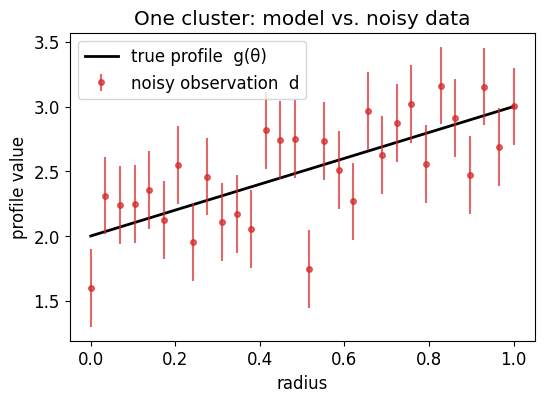

In [2]:
N_R   = 30                              # number of radial bins in a profile
radii = np.linspace(0.0, 1.0, N_R)      # the "radius" of each bin (arbitrary units)

# Design matrix: a column of ones (amplitude) and a linear ramp (tilt).
X = np.column_stack([np.ones(N_R), radii])

def forward_model(theta):
    # Predict the NOISELESS profile for parameters theta = (amplitude, tilt).
    return X @ np.asarray(theta, dtype=float)

# Visualise a single cluster: the true profile and one noisy 'observation'.
theta_example = np.array([2.0, 1.0])    # amplitude = 2, tilt = 1
noise_sigma   = 0.30                    # measurement noise per radial bin (1 sigma)

clean_profile = forward_model(theta_example)
noisy_profile = clean_profile + noise_sigma * np.random.randn(N_R)

plt.figure()
plt.plot(radii, clean_profile, "k-", lw=2, label="true profile  g(θ)")
plt.errorbar(radii, noisy_profile, yerr=noise_sigma, fmt="o", ms=4,
             color="tab:red", alpha=0.7, label="noisy observation  d")
plt.xlabel("radius"); plt.ylabel("profile value")
plt.title("One cluster: model vs. noisy data"); plt.legend(); plt.show()

## 2. Inferring **one** cluster: likelihood, prior, posterior

For a single cluster with observed profile $d=(\Sigma^{\rm obs}_1,\dots,\Sigma^{\rm obs}_{N_r})$ and
independent Gaussian noise $\sigma_i$ per bin, the likelihood is a product of Gaussians, so the
**log-likelihood** is

$$\ln\mathcal L(\theta)=-\frac12\sum_{i=1}^{N_r}
   \left[\frac{\big(\Sigma^{\rm obs}_i-\Sigma_i(\theta)\big)^2}{\sigma_i^2}+\ln\!\big(2\pi\sigma_i^2\big)\right].$$

We use a **flat (uniform) prior** $\pi(\theta)=\text{const}$ on a wide box, so the posterior $\propto$ the
likelihood. Below we (i) write the likelihood, prior and posterior as separate functions, (ii) write a small
reusable `run_mcmc` helper, and (iii) sample the posterior for the one noisy cluster from Part 1.

ONE cluster -> posterior on (amplitude, tilt):
   mean : [2.044 0.925]
   std  : [0.109 0.184]  <- the uncertainty from a single noisy cluster


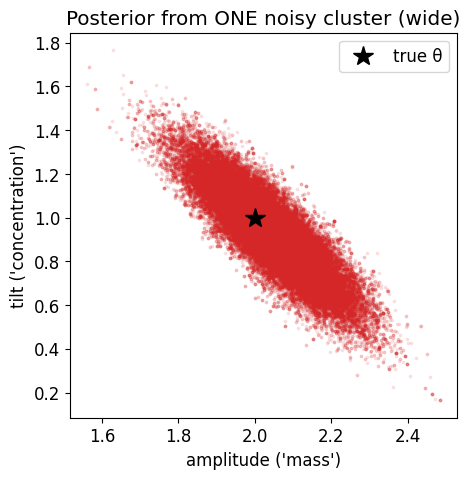

In [3]:
def log_likelihood_one_cluster(theta, observed_profile, sigma):
    # Gaussian log-likelihood for a single cluster (constant 2*pi term dropped).
    residual = observed_profile - forward_model(theta)
    return -0.5 * np.sum(residual**2 / sigma**2)

def log_prior(theta):
    # Flat prior on a wide box: log-prob = 0 inside, -inf outside.
    amplitude, tilt = theta
    if -100 < amplitude < 100 and -100 < tilt < 100:
        return 0.0
    return -np.inf

def log_posterior_one_cluster(theta, observed_profile, sigma):
    # log posterior = log prior + log likelihood (Bayes' theorem, up to a constant).
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_one_cluster(theta, observed_profile, sigma)

def run_mcmc(log_post, args, start, n_walkers=40, n_burn=500, n_steps=2000):
    # Sample a posterior with emcee; returns flat samples of shape (n_walkers*n_steps, n_dim).
    #   log_post : function(theta, *args) -> log posterior probability
    #   args     : tuple of extra arguments passed to log_post
    #   start    : rough starting point (1-D array of length n_dim)
    n_dim   = len(start)
    initial = start + 0.1 * np.random.randn(n_walkers, n_dim)   # scatter the walkers around `start`
    sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_post, args=args)
    state = sampler.run_mcmc(initial, n_burn, progress=False)   # burn-in (let walkers settle)
    sampler.reset()                                             # discard burn-in
    sampler.run_mcmc(state, n_steps, progress=False)            # production run we keep
    return sampler.get_chain(flat=True)

# Sample the posterior for the single noisy cluster.
samples_one = run_mcmc(log_posterior_one_cluster,
                       args=(noisy_profile, noise_sigma),
                       start=theta_example)

print("ONE cluster -> posterior on (amplitude, tilt):")
print("   mean :", samples_one.mean(axis=0).round(3))
print("   std  :", samples_one.std(axis=0).round(3), " <- the uncertainty from a single noisy cluster")

plt.figure(figsize=(5, 5))
plt.scatter(samples_one[:, 0], samples_one[:, 1], s=3, alpha=0.1, color="tab:red")
plt.plot(*theta_example, "k*", ms=15, label="true θ")
plt.xlabel("amplitude ('mass')"); plt.ylabel("tilt ('concentration')")
plt.title("Posterior from ONE noisy cluster (wide)"); plt.legend(); plt.show()

The single-cluster posterior is **broad** — one noisy profile does not pin down $\theta$ well. The whole
point of "stacking" many clusters is to shrink this. Next we build a *population* of clusters.

## 3. Many clusters are a **population**

In reality every cluster has its *own* true parameters $\theta_j$, and those scatter around a population
mean. We model the population as a Gaussian:

$$\theta_j \sim \mathcal N\!\big(\boldsymbol\mu_{\rm pop},\,\mathrm{diag}(\boldsymbol s_{\rm pop}^2)\big),
   \qquad d_j = g(\theta_j) + \text{noise}.$$

Below we draw $N_c=20$ clusters: each gets a true $\theta_j$ from the population and then a noisy profile.

Drew 20 clusters.  profiles array shape = (20, 30) (clusters x bins)


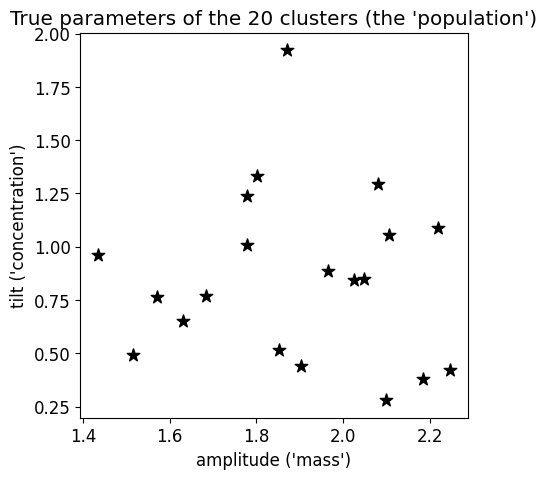

In [4]:
n_clusters  = 20
pop_mean    = np.array([2.0, 1.0])      # population MEAN of (amplitude, tilt)
pop_scatter = np.array([0.30, 0.50])    # population SCATTER (cluster-to-cluster spread)

# Each cluster: draw its true parameters from the population, then make a noisy profile.
theta_true = pop_mean + pop_scatter * np.random.randn(n_clusters, 2)
profiles   = np.array([forward_model(theta_true[j]) + noise_sigma * np.random.randn(N_R)
                       for j in range(n_clusters)])

print("Drew", n_clusters, "clusters.  profiles array shape =", profiles.shape, "(clusters x bins)")

plt.figure(figsize=(5, 5))
plt.scatter(theta_true[:, 0], theta_true[:, 1], c="k", marker="*", s=90)
plt.xlabel("amplitude ('mass')"); plt.ylabel("tilt ('concentration')")
plt.title("True parameters of the %d clusters (the 'population')" % n_clusters); plt.show()

## 4. Two ways to **stack**, plus the textbook-correct version

A single cluster gives a wide posterior, so we combine the $N_c$ clusters. There are two philosophies — and
the second one has a *correct* form and a *buggy* form that differ only by a factor of $N_c$:

**(a) Join-then-fit (JtF)** — *join the data first*, then fit once. Use the **median** profile
$\tilde\Sigma$; the standard error of the median of $N_c$ Gaussians is $\tilde\sigma_i=\sqrt{\pi/2}\,
\sigma_i/\sqrt{N_c}$, so
$$\ln\mathcal L_{\rm JtF}(\theta)=-\tfrac12\sum_i\frac{(\tilde\Sigma_i-\Sigma_i(\theta))^2}{\tilde\sigma_i^2}.$$

**(b) Fit-then-join (FtJ), as printed in the paper** — compares the model to *every* cluster, **but divides
by $N_c$**:
$$\ln\mathcal L_{\rm FtJ}(\theta)=-\frac{1}{2N_c}\sum_{j=1}^{N_c}\sum_i
   \frac{(\Sigma_{i,j}-\Sigma_i(\theta))^2}{\sigma^2}.$$

**(c) The correct joint likelihood** — $N_c$ independent clusters that share one $\theta$ **multiply** their
likelihoods, so their log-likelihoods **add** (no $1/N_c$):
$$\ln\mathcal L_{\rm joint}(\theta)=\sum_j\ln\mathcal L_j(\theta)
   =-\tfrac12\sum_j\sum_i\frac{(\Sigma_{i,j}-\Sigma_i(\theta))^2}{\sigma^2}.$$

The *only* difference between (b) and (c) is that factor $1/N_c$. Let's implement all three and compare.

In [5]:
# --- (a) join-then-fit: combine the data, then fit once ---
median_profile = np.median(profiles, axis=0)               # the 'join' step
sigma_tilde_sq = (np.pi / 2) * noise_sigma**2 / n_clusters # squared std-error of the median

def loglike_JtF(theta):
    residual = median_profile - forward_model(theta)
    return -0.5 * np.sum(residual**2 / sigma_tilde_sq)

# --- (b) paper fit-then-join: note the 1/N_c that AVERAGES the per-cluster chi-squareds ---
def loglike_FtJ_paper(theta):
    model = forward_model(theta)
    chi2_each_cluster = np.sum((profiles - model)**2 / noise_sigma**2, axis=1)
    return -(1.0 / (2 * n_clusters)) * np.sum(chi2_each_cluster)

# --- (c) correct joint: SUM the per-cluster chi-squareds (no 1/N_c) ---
def loglike_joint_correct(theta):
    model = forward_model(theta)
    chi2_each_cluster = np.sum((profiles - model)**2 / noise_sigma**2, axis=1)
    return -0.5 * np.sum(chi2_each_cluster)

def add_flat_prior(loglike):
    # Turn a log-likelihood into a log-posterior with our flat box prior.
    def log_post(theta):
        return loglike(theta) if np.isfinite(log_prior(theta)) else -np.inf
    return log_post

samples_JtF   = run_mcmc(add_flat_prior(loglike_JtF),            args=(), start=pop_mean)
samples_FtJ   = run_mcmc(add_flat_prior(loglike_FtJ_paper),      args=(), start=pop_mean)
samples_joint = run_mcmc(add_flat_prior(loglike_joint_correct), args=(), start=pop_mean)

def width_amplitude(samples):
    # Posterior uncertainty (std) on the amplitude, theta_0.
    return samples[:, 0].std()

print("posterior width on the amplitude (theta_0):")
print("   join-then-fit (JtF)  : %.4f" % width_amplitude(samples_JtF))
print("   fit-then-join (paper): %.4f   <- has the 1/N_c" % width_amplitude(samples_FtJ))
print("   correct joint (sum)  : %.4f" % width_amplitude(samples_joint))
print()
print("ratios (and the exact Gaussian prediction):")
print("   FtJ / JtF            = %.2f   (sqrt(2 N_c / pi) = %.2f)"
      % (width_amplitude(samples_FtJ)/width_amplitude(samples_JtF), np.sqrt(2*n_clusters/np.pi)))
print("   FtJ / correct joint  = %.2f   (sqrt(N_c)        = %.2f)"
      % (width_amplitude(samples_FtJ)/width_amplitude(samples_joint), np.sqrt(n_clusters)))

posterior width on the amplitude (theta_0):
   join-then-fit (JtF)  : 0.0303
   fit-then-join (paper): 0.1069   <- has the 1/N_c
   correct joint (sum)  : 0.0242

ratios (and the exact Gaussian prediction):
   FtJ / JtF            = 3.53   (sqrt(2 N_c / pi) = 3.57)
   FtJ / correct joint  = 4.42   (sqrt(N_c)        = 4.47)


So at $N_c=20$ the paper's FtJ posterior is about $\sqrt{N_c}\approx4.5\times$ wider than a correct joint
fit, and $\sqrt{2N_c/\pi}\approx3.6\times$ wider than JtF. JtF and the correct joint agree to the small
$\sqrt{\pi/2}\approx1.25$ factor (the price of using the median). Let's draw the $2\sigma$ contours to see it.

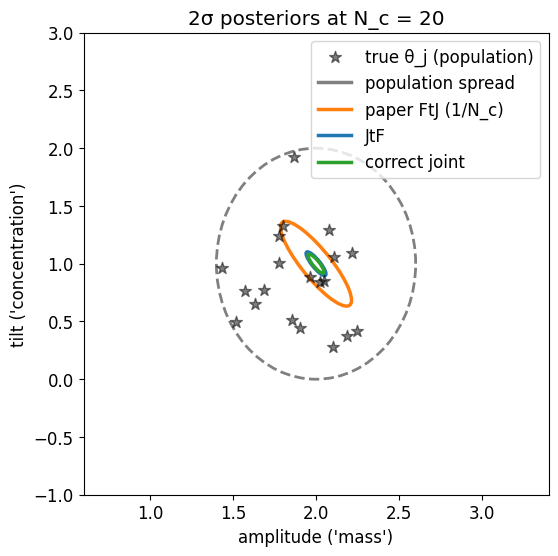

In [6]:
from matplotlib.patches import Ellipse

def draw_cov_ellipse(ax, center, cov, n_sigma=2.0, **kwargs):
    # Draw an n-sigma ellipse for a 2x2 covariance matrix.
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]; vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    w, h = 2 * n_sigma * np.sqrt(vals)
    ax.add_patch(Ellipse(center, w, h, angle=angle, fill=False, **kwargs))

# Exact Gaussian covariances for the three methods (centre them at the population mean for display).
XtX_inv  = np.linalg.inv(X.T @ X)
cov_JtF   = sigma_tilde_sq * XtX_inv                       # (pi/2) sigma^2 / N_c * (X^T X)^-1
cov_FtJ   = noise_sigma**2 * XtX_inv                       # sigma^2 * (X^T X)^-1  (NO 1/N_c shrink)
cov_joint = noise_sigma**2 / n_clusters * XtX_inv          # sigma^2 / N_c * (X^T X)^-1

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(theta_true[:, 0], theta_true[:, 1], marker="*", s=80, color="k", alpha=0.5,
           zorder=5, label="true θ_j (population)")
draw_cov_ellipse(ax, pop_mean, np.diag(pop_scatter**2), color="gray",       lw=2, ls="--")
draw_cov_ellipse(ax, pop_mean, cov_FtJ,                 color="tab:orange", lw=2.5)
draw_cov_ellipse(ax, pop_mean, cov_JtF,                 color="tab:blue",   lw=2.5)
draw_cov_ellipse(ax, pop_mean, cov_joint,               color="tab:green",  lw=2.5)
for label, colour in [("population spread", "gray"), ("paper FtJ (1/N_c)", "tab:orange"),
                      ("JtF", "tab:blue"), ("correct joint", "tab:green")]:
    ax.plot([], [], color=colour, lw=2.5, label=label)
ax.set_xlim(pop_mean[0]-1.4, pop_mean[0]+1.4); ax.set_ylim(pop_mean[1]-2, pop_mean[1]+2)
ax.set_xlabel("amplitude ('mass')"); ax.set_ylabel("tilt ('concentration')")
ax.set_title("2σ posteriors at N_c = 20"); ax.legend(loc="upper right"); plt.show()

Notice the orange **FtJ** contour is almost as broad as the **population spread** (dashed gray). That is a
trap: FtJ is *not* estimating the population — it is just stuck at single-cluster width, which happens to
resemble the spread here. We make that precise next.

## 5. The key diagnostic: does adding clusters help?

Intuition: **more clusters should give a tighter answer**, with the uncertainty falling like $1/\sqrt{N_c}$.
Let's plot each method's width as a function of $N_c$. We use the exact Gaussian formulas (already confirmed
to match the MCMC above), so the sweep is instant.

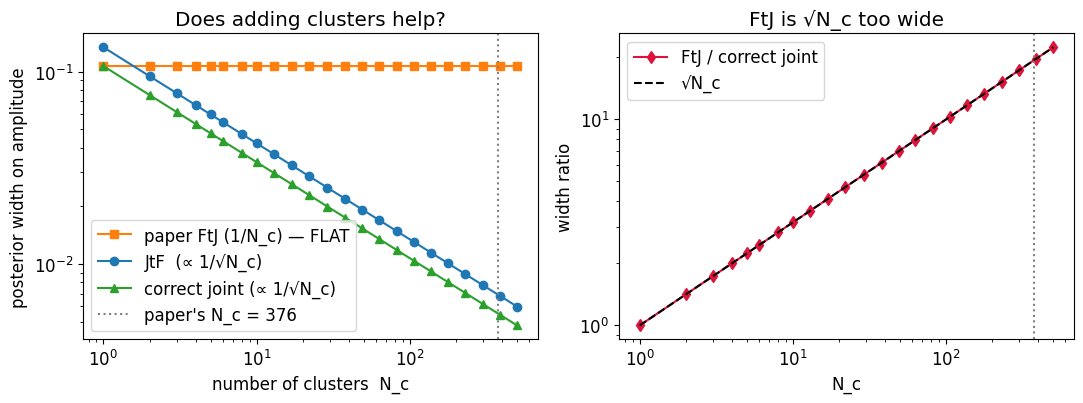

In [7]:
base_width = np.sqrt(XtX_inv[0, 0])                 # single-cluster width factor for theta_0
Nc_grid    = np.unique(np.round(np.logspace(0, 2.7, 25)).astype(int))   # 1 ... ~500 clusters

width_JtF_vs_Nc   = np.sqrt(np.pi/2) * noise_sigma * base_width / np.sqrt(Nc_grid)  # ~ 1/sqrt(Nc)
width_joint_vs_Nc = noise_sigma * base_width / np.sqrt(Nc_grid)                     # ~ 1/sqrt(Nc)
width_FtJ_vs_Nc   = noise_sigma * base_width * np.ones_like(Nc_grid, dtype=float)   # CONSTANT in Nc!

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.2))
axL.loglog(Nc_grid, width_FtJ_vs_Nc,   "s-", color="tab:orange", label="paper FtJ (1/N_c) — FLAT")
axL.loglog(Nc_grid, width_JtF_vs_Nc,   "o-", color="tab:blue",   label="JtF  (∝ 1/√N_c)")
axL.loglog(Nc_grid, width_joint_vs_Nc, "^-", color="tab:green",  label="correct joint (∝ 1/√N_c)")
axL.axvline(376, color="gray", ls=":", label="paper's N_c = 376")
axL.set_xlabel("number of clusters  N_c"); axL.set_ylabel("posterior width on amplitude")
axL.set_title("Does adding clusters help?"); axL.legend()

axR.loglog(Nc_grid, width_FtJ_vs_Nc / width_joint_vs_Nc, "d-", color="crimson", label="FtJ / correct joint")
axR.loglog(Nc_grid, np.sqrt(Nc_grid), "k--", label="√N_c")
axR.axvline(376, color="gray", ls=":")
axR.set_xlabel("N_c"); axR.set_ylabel("width ratio"); axR.set_title("FtJ is √N_c too wide"); axR.legend()
plt.tight_layout(); plt.show()

**What you are seeing.** JtF and the correct joint both fall as $1/\sqrt{N_c}$ — stacking helps. But the
paper's **FtJ is a flat line**: its uncertainty *never improves*, no matter how many clusters you add.

**Why.** The correct joint adds $N_c$ chi-squared terms, so the information grows $\propto N_c$ and the width
shrinks $\propto 1/\sqrt{N_c}$. Dividing by $N_c$ turns that **sum** into an **average** — the information of
a *single* typical cluster, independent of $N_c$. At the paper's $N_c=376$ that makes FtJ about
$\sqrt{376}\approx 19\times$ too wide.

**The fix:** drop the $1/N_c$ (use a sum). FtJ then becomes a genuine joint fit and matches JtF.

## 6. The same thing on the **real NFW** model *(optional — needs Colossus)*

To show this isn't an artifact of the toy, we repeat the JtF-vs-FtJ comparison with the real NFW forward
model. FtJ stays flat in $N_c$; JtF shrinks.

In [8]:
try:
    from colossus.cosmology import cosmology
    from colossus.halo import profile_nfw
    cosmology.setCosmology("planck18")
    nfw_radii = 10**np.arange(0, 3, 0.1)                      # 30 radial bins (kpc/h)
    dex_noise = 0.3                                           # log-normal profile noise (0.3 dex)

    def nfw_forward(theta):
        # Real NFW: log10 of the density profile for theta = (log10 mass, concentration).
        log10_mass, concentration = theta
        halo = profile_nfw.NFWProfile(M=10**log10_mass, c=concentration, z=0.0, mdef="vir")
        return np.log10(halo.density(nfw_radii))

    def nfw_in_bounds(theta):
        return 10 < theta[0] < 18 and 0.5 < theta[1] < 30

    for Nc in (8, 32):
        masses = 14.2 + 0.08 * np.random.randn(Nc)
        concs  = 5.0  + 0.5  * np.random.randn(Nc)
        prof   = np.array([nfw_forward([masses[j], concs[j]]) + dex_noise * np.random.randn(len(nfw_radii))
                           for j in range(Nc)])
        median = np.median(prof, axis=0)
        st2    = (np.pi / 2) * dex_noise**2 / Nc

        def ll_jtf(t, median=median, st2=st2):
            return -0.5 * np.sum((nfw_forward(t) - median)**2 / st2) if nfw_in_bounds(t) else -np.inf
        def ll_ftj(t, prof=prof, Nc=Nc):
            return -(1/(2*Nc)) * np.sum((nfw_forward(t)[None, :] - prof)**2 / dex_noise**2) if nfw_in_bounds(t) else -np.inf

        s_jtf = run_mcmc(ll_jtf, args=(), start=np.array([14.2, 5.0]), n_walkers=40, n_burn=200, n_steps=700)
        s_ftj = run_mcmc(ll_ftj, args=(), start=np.array([14.2, 5.0]), n_walkers=40, n_burn=200, n_steps=700)
        print("NFW, N_c=%2d :  JtF width(log10 M) = %.4f   FtJ width = %.4f   ->  FtJ/JtF = %.2f"
              % (Nc, s_jtf[:, 0].std(), s_ftj[:, 0].std(), s_ftj[:, 0].std() / s_jtf[:, 0].std()))
except Exception as exc:
    print("Colossus not available; skipping the real-NFW check:", exc)

NFW, N_c= 8 :  JtF width(log10 M) = 0.0571   FtJ width = 0.1348   ->  FtJ/JtF = 2.36


NFW, N_c=32 :  JtF width(log10 M) = 0.0316   FtJ width = 0.1394   ->  FtJ/JtF = 4.41


## 7. The right tool for the **population**: hierarchical Bayesian inference

Every method so far estimates **one** $\theta$ shared by all clusters — i.e. the population *mean*. But we
often want the population itself: its **mean $\mu$** and its **intrinsic scatter $\tau$** (e.g. the mean
mass–observable relation and how tightly clusters follow it). A single shared-$\theta$ fit can *never* give
the scatter.

The correct model is **hierarchical**: each cluster has its own latent $\theta_j$, drawn from a population
controlled by hyperparameters $\Lambda=(\mu,\tau)$:

$$\theta_j \sim p(\theta\mid\Lambda),\qquad d_j\mid\theta_j \sim (\text{per-cluster likelihood}).$$

We want the **hyper-posterior** $p(\Lambda\mid\{d_j\})$. Integrating out (marginalising) each cluster's
latent $\theta_j$:

$$p(\Lambda\mid\{d_j\}) \;\propto\; p(\Lambda)\prod_{j=1}^{N_c}
   \underbrace{\int p(d_j\mid\theta_j)\,p(\theta_j\mid\Lambda)\,d\theta_j}_{\text{per-cluster evidence}}.$$

**Posterior reuse (the "gravitational-wave trick").** Re-doing that integral for every trial $\Lambda$ is
expensive. But if a pipeline already produced posterior **samples** $\theta_j^{(s)}\sim p(\theta_j\mid d_j)$
(under some interim prior $\pi$), we can rewrite the integral as an average over those *stored* samples:

$$\int p(d_j\mid\theta)\,p(\theta\mid\Lambda)\,d\theta
   = Z_j\,\mathbb E_{\theta\sim p(\theta\mid d_j)}\!\Big[\tfrac{p(\theta\mid\Lambda)}{\pi(\theta)}\Big]
   \;\approx\; \frac{Z_j}{S}\sum_{s=1}^{S}\frac{p(\theta_j^{(s)}\mid\Lambda)}{\pi(\theta_j^{(s)})}.$$

With a **flat** interim prior this is just $\propto \tfrac1S\sum_s p(\theta_j^{(s)}\mid\Lambda)$ — **no new
likelihood evaluations**. That is why the per-cluster posteriors a pipeline already saved can be *reused* for
the population step.

For a clean demo we use a 1-D version: each cluster has a true (log-)mass $m_j\sim\mathcal N(\mu,\tau^2)$ and
one noisy measurement $d_j\sim\mathcal N(m_j,\sigma^2)$. We compare three estimates of $(\mu,\tau)$:
**(C) exact** analytic hyper-posterior (the truth), **(B) reuse** (importance sampling the stored samples),
and **naive pool** (just lumping all samples together — a common mistake).

In [9]:
np.random.seed(7)   # fresh, self-contained example

# --- 1. Simulate the population and one noisy measurement per cluster ---
n_clusters_h = 60
mu_true, tau_true = 14.20, 0.30      # population mean (log-mass) and intrinsic scatter
meas_sigma        = 0.30            # measurement noise per cluster

true_masses = mu_true + tau_true * np.random.randn(n_clusters_h)     # latent m_j
data_h      = true_masses + meas_sigma * np.random.randn(n_clusters_h)  # observed d_j

# --- 2. Each cluster's posterior p(m_j | d_j).  Flat prior -> Normal(d_j, sigma^2). ---
#     These stand in for the samples a real SBI/MCMC pipeline would have stored on disk.
n_post = 4000
cluster_post_samples = np.array(
    [data_h[j] + meas_sigma * np.random.randn(n_post) for j in range(n_clusters_h)])

# --- 3. (C) EXACT analytic hyper-posterior on a (mu, tau) grid (the ground truth) ---
#     Marginalising m_j analytically: p(d_j | mu, tau) = Normal(d_j; mu, sigma^2 + tau^2).
mu_axis  = np.linspace(data_h.mean() - 0.4, data_h.mean() + 0.4, 300)
tau_axis = np.linspace(0.05, 1.2, 300)
MU, TAU  = np.meshgrid(mu_axis, tau_axis, indexing="ij")
total_var = meas_sigma**2 + TAU**2
log_grid  = -0.5 * np.sum((data_h[:, None, None] - MU[None])**2 / total_var[None]
                          + np.log(2 * np.pi * total_var)[None], axis=0)
post_grid = np.exp(log_grid - log_grid.max()); post_grid /= post_grid.sum()
mu_exact  = float(np.sum(MU  * post_grid))
tau_exact = float(np.sum(TAU * post_grid))

# --- 4. (B) REUSE: importance-sample the stored per-cluster posteriors ---
#     hyper log-likelihood(mu, tau) = sum_j log[ mean_s Normal(theta^s | mu, tau) ]
#     (the flat interim prior pi cancels, so we just average the population density over stored samples).
def hyper_log_posterior(params):
    mu, log_tau = params
    tau = np.exp(log_tau)
    if tau > 5:
        return -np.inf
    total = 0.0
    for j in range(n_clusters_h):
        density = np.exp(-0.5 * ((cluster_post_samples[j] - mu) / tau)**2) / tau   # p(theta^s | mu, tau)
        total += np.log(density.mean() + 1e-300)
    return total + log_tau    # + log_tau is the Jacobian for sampling in log(tau)

reuse_chain = run_mcmc(hyper_log_posterior, args=(),
                       start=np.array([mu_true, np.log(0.3)]),
                       n_walkers=12, n_burn=1500, n_steps=3000)
mu_reuse  = reuse_chain[:, 0].mean()
tau_reuse = np.exp(reuse_chain[:, 1]).mean()

# --- 5. naive pool: lump ALL per-cluster samples together (this OVER-counts the noise) ---
pooled    = cluster_post_samples.ravel()
tau_naive = pooled.std()

print("                       mu        tau")
print("truth              : %.3f     %.3f" % (mu_true, tau_true))
print("(C) exact analytic : %.3f     %.3f   <- ground truth" % (mu_exact, tau_exact))
print("(B) reuse          : %.3f     %.3f   <- matches (C), and it is cheap" % (mu_reuse, tau_reuse))
print("naive pool         : %.3f     %.3f   <- too big:  sqrt(tau^2 + 2 sigma^2) = %.3f"
      % (pooled.mean(), tau_naive, np.sqrt(tau_true**2 + 2 * meas_sigma**2)))

                       mu        tau
truth              : 14.200     0.300
(C) exact analytic : 14.219     0.340   <- ground truth
(B) reuse          : 14.217     0.338   <- matches (C), and it is cheap
naive pool         : 14.218     0.535   <- too big:  sqrt(tau^2 + 2 sigma^2) = 0.520


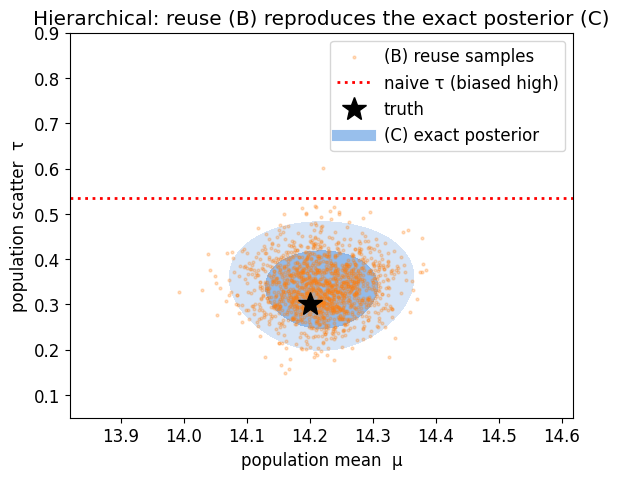

In [10]:
# Visualise the hyper-posterior on (mu, tau): exact (filled) vs reuse (points) vs naive (line).
flat = np.sort(post_grid.ravel())[::-1]
cdf  = np.cumsum(flat) / flat.sum()
levels = sorted(float(flat[np.searchsorted(cdf, q)]) for q in (0.95, 0.68))   # 95% then 68%

tau_reuse_samples = np.exp(reuse_chain[:, 1])
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.contourf(MU, TAU, post_grid, levels=levels + [post_grid.max()],
            colors=["#cfe0f5", "#7fb0e8"], alpha=0.85)
ax.scatter(reuse_chain[::25, 0], tau_reuse_samples[::25], s=4, alpha=0.25,
           color="tab:orange", label="(B) reuse samples")
ax.axhline(tau_naive, color="r", ls=":", lw=2, label="naive τ (biased high)")
ax.plot(mu_true, tau_true, "k*", ms=18, label="truth")
ax.plot([], [], color="#7fb0e8", lw=8, alpha=0.8, label="(C) exact posterior")
ax.set_ylim(0.05, 0.9)
ax.set_xlabel("population mean  μ"); ax.set_ylabel("population scatter  τ")
ax.set_title("Hierarchical: reuse (B) reproduces the exact posterior (C)")
ax.legend(loc="upper right"); plt.show()

**What you are seeing.** The cheap **reuse** estimate (orange) lands right on the **exact** posterior
(blue), recovering both $\mu$ and $\tau$. The **naive pool** (red line) badly over-estimates the scatter,
because pooling the posterior samples adds the measurement noise *on top of* the intrinsic scatter — it never
deconvolves them. Concretely it returns $\sqrt{\tau^2+2\sigma^2}$ instead of $\tau$.

## 8. Summary

1. **A single noisy cluster is uninformative;** stacking many clusters should sharpen the answer as
   $1/\sqrt{N_c}$.
2. **Join-then-fit and a correct joint fit both do that.** But the paper's **fit-then-join has a `1/N_c`**
   that makes its uncertainty **flat in $N_c$** — single-cluster precision no matter how many clusters you
   stack, hence $\sqrt{N_c}$ too wide (~19× at $N_c=376$). **Fix: drop the `1/N_c` (use a sum).**
3. **A single shared-$\theta$ fit only gives the population mean, never the scatter.** For the scatter you
   need a **hierarchical model**, and **posterior reuse** (importance sampling stored per-cluster posteriors)
   computes it cheaply and matches the exact answer — while naive pooling is biased.

*Next step for a real analysis:* replace the toy Gaussian per-cluster posteriors in Part 7 with the actual
posterior samples a pipeline (SBI or MCMC) saved for each cluster — the reuse math is identical.

In [11]:
import os
out_dir = "slide_figures"; os.makedirs(out_dir, exist_ok=True)
plt.rcParams.update({"savefig.dpi": 200, "savefig.bbox": "tight"})

# headline 1: width vs N_c
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.2))
axL.loglog(Nc_grid, width_FtJ_vs_Nc, "s-", color="tab:orange", label="paper FtJ (1/N_c) — FLAT")
axL.loglog(Nc_grid, width_JtF_vs_Nc, "o-", color="tab:blue",   label="JtF (∝ 1/√N_c)")
axL.loglog(Nc_grid, width_joint_vs_Nc, "^-", color="tab:green", label="correct joint")
axL.axvline(376, color="gray", ls=":"); axL.set_xlabel("N_c"); axL.set_ylabel("posterior width")
axL.set_title("FtJ never shrinks with N_c"); axL.legend()
axR.loglog(Nc_grid, width_FtJ_vs_Nc/width_joint_vs_Nc, "d-", color="crimson", label="FtJ / correct joint")
axR.loglog(Nc_grid, np.sqrt(Nc_grid), "k--", label="√N_c"); axR.axvline(376, color="gray", ls=":")
axR.set_xlabel("N_c"); axR.set_ylabel("ratio"); axR.set_title("FtJ is √N_c too wide"); axR.legend()
fig.tight_layout(); fig.savefig(f"{out_dir}/fig_width_vs_Nc.png"); plt.close(fig)

# headline 2: hierarchical reuse vs exact
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.contourf(MU, TAU, post_grid, levels=levels + [post_grid.max()], colors=["#cfe0f5", "#7fb0e8"], alpha=0.85)
ax.scatter(reuse_chain[::25, 0], tau_reuse_samples[::25], s=4, alpha=0.25, color="tab:orange", label="(B) reuse")
ax.axhline(tau_naive, color="r", ls=":", lw=2, label="naive τ"); ax.plot(mu_true, tau_true, "k*", ms=16, label="truth")
ax.plot([], [], color="#7fb0e8", lw=8, alpha=0.8, label="(C) exact"); ax.set_ylim(0.05, 0.9)
ax.set_xlabel("μ"); ax.set_ylabel("τ"); ax.set_title("HBI reuse = exact posterior"); ax.legend(loc="upper right")
fig.tight_layout(); fig.savefig(f"{out_dir}/fig_hbi_mu_tau.png"); plt.close(fig)
print("saved slide figures to", out_dir, "->", os.listdir(out_dir))

saved slide figures to slide_figures -> ['fig_naive_bias.png', 'fig_contours_ftj_jtf.png', 'fig_width_vs_noise.png', 'fig_width_vs_Nc.png', 'fig_hbi_mu_tau.png']
